# Adult Income Dataset - Exploratory Data Analysis
This notebook visualizes the preprocessed dataset `adult_preprocessed.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv("adult_preprocessed.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [2]:
print(df.shape)
df.info()
df.describe()

(32537, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education.num   32537 non-null  int64
 5   marital.status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital.gain    32537 non-null  int64
 11  capital.loss    32537 non-null  int64
 12  hours.per.week  32537 non-null  int64
 13  native.country  32537 non-null  int64
 14  income          32537 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32537.000000,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,3.094446,1.897808e+05,10.297507,10.081815,2.611427,6.139288,1.446538,3.665827,0.669238,1078.443741,87.368227,40.440329,36.419184,0.240926
std,13.637984,1.107549,1.055565e+05,3.870142,2.571633,1.506301,3.973173,1.607064,0.848847,0.470495,7387.957424,403.101833,12.346889,6.053816,0.427652
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,3.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,38.000000,0.000000
50%,37.000000,3.000000,1.783560e+05,11.000000,10.000000,2.000000,6.000000,1.000000,4.000000,1.000000,0.000000,0.000000,40.000000,38.000000,0.000000
75%,48.000000,3.000000,2.369930e+05,12.000000,12.000000,4.000000,9.000000,3.000000,4.000000,1.000000,0.000000,0.000000,45.000000,38.000000,0.000000
max,90.000000,7.000000,1.484705e+06,15.000000,16.000000,6.000000,13.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,40.000000,1.000000


## Target Distribution

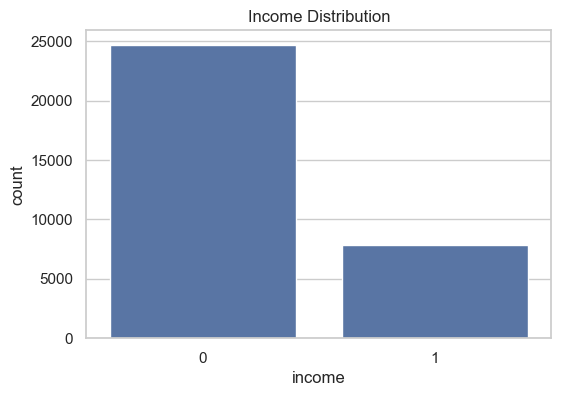

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

## Numeric Feature Histograms

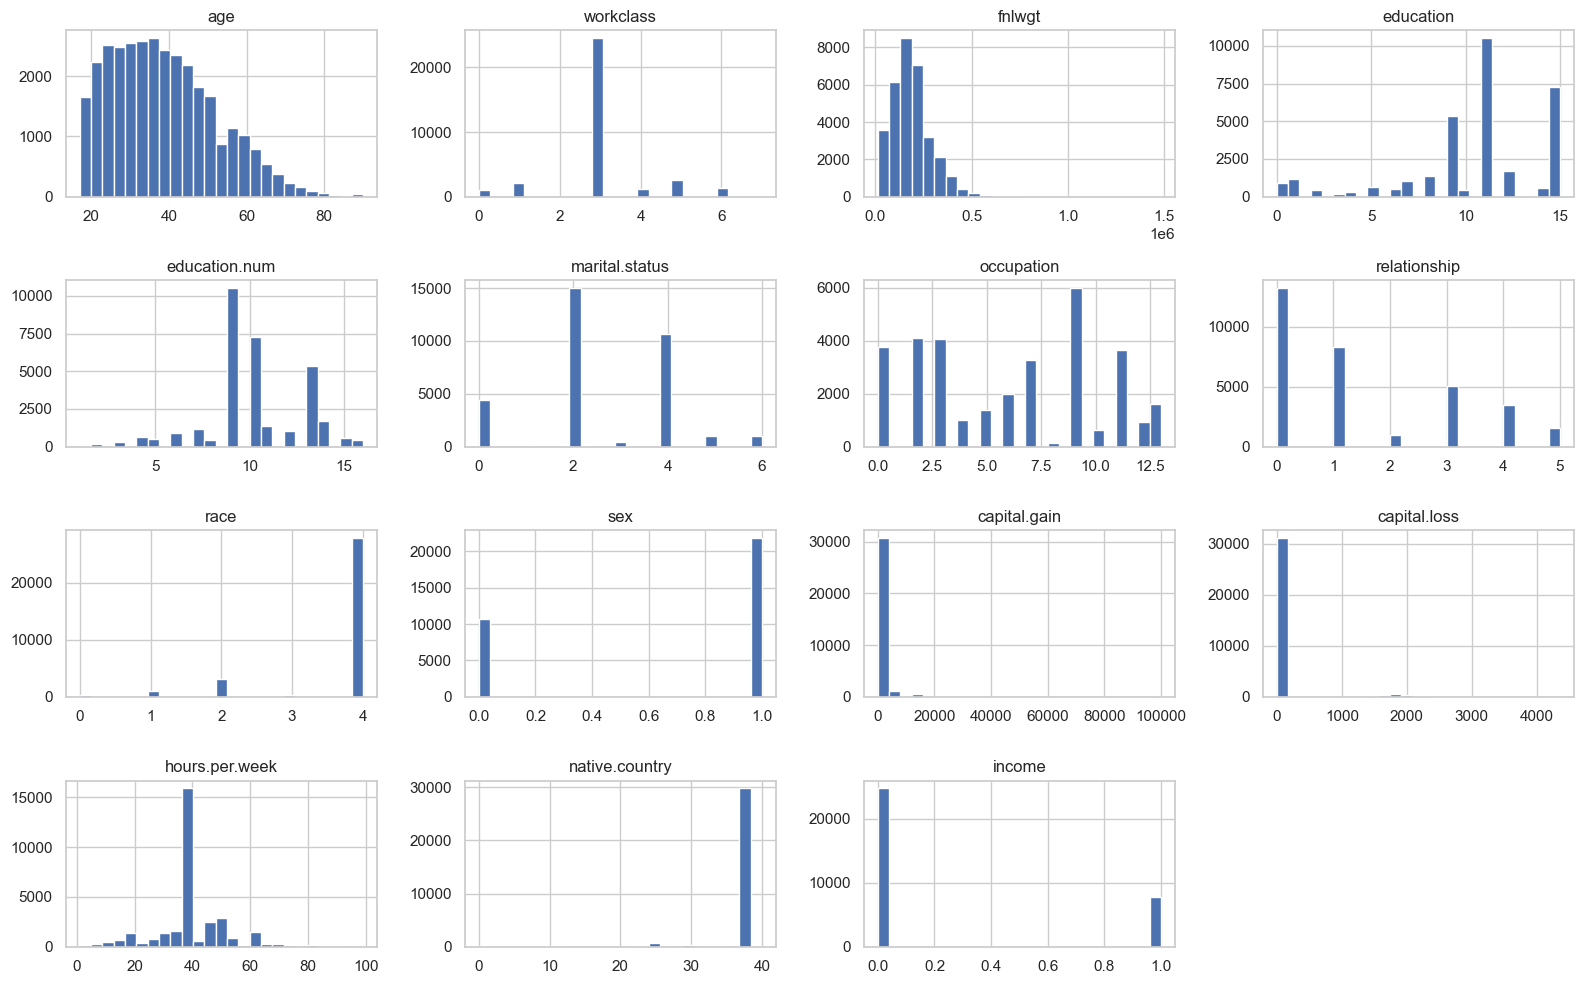

In [4]:
numeric_cols=df.select_dtypes(include=["int64","float64"]).columns
df[numeric_cols].hist(figsize=(16,10),bins=25)
plt.tight_layout()
plt.show()

## Boxplots

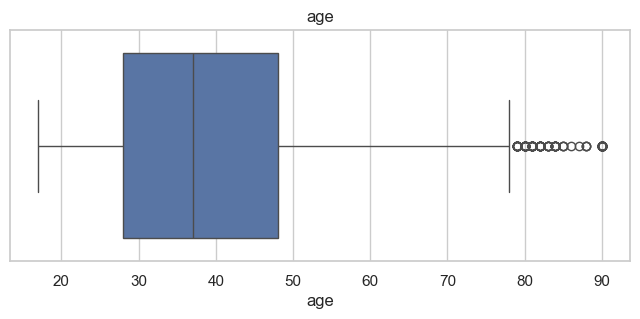

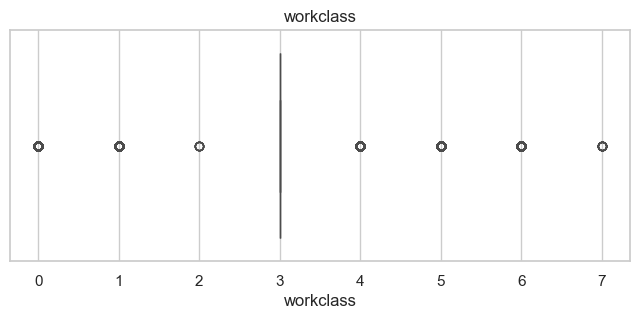

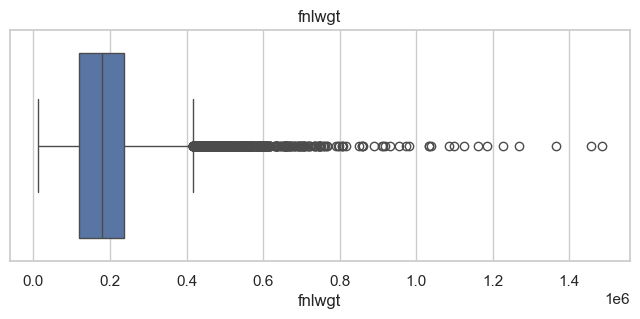

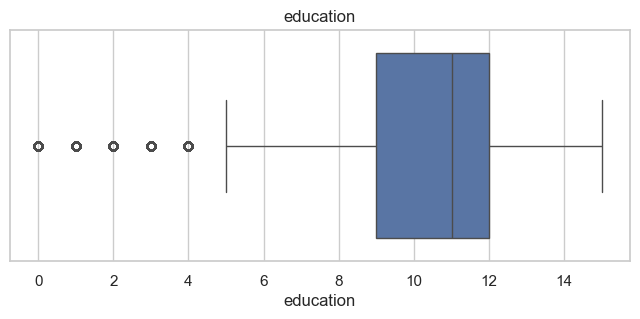

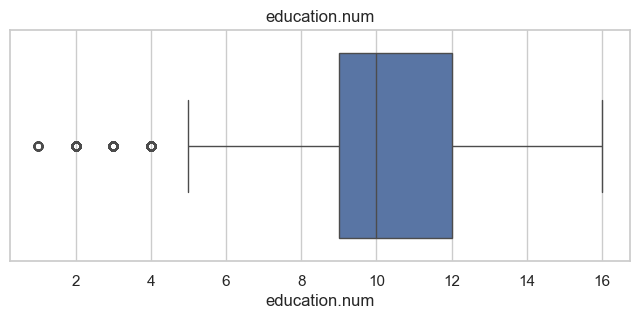

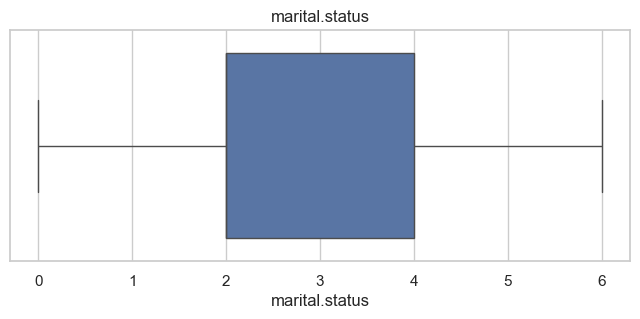

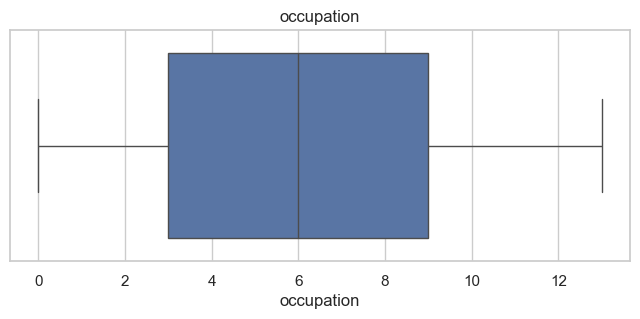

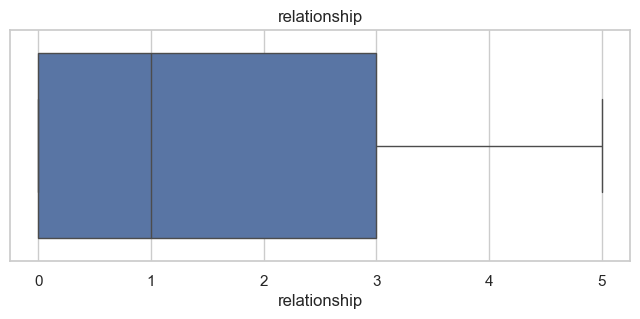

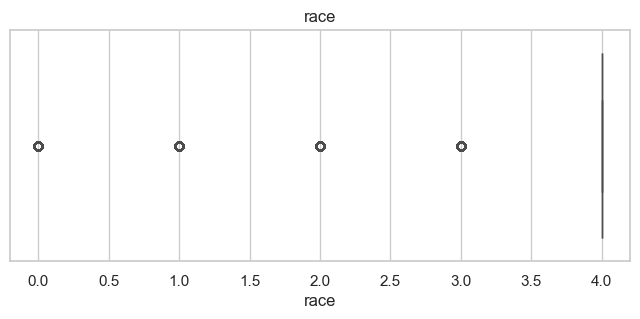

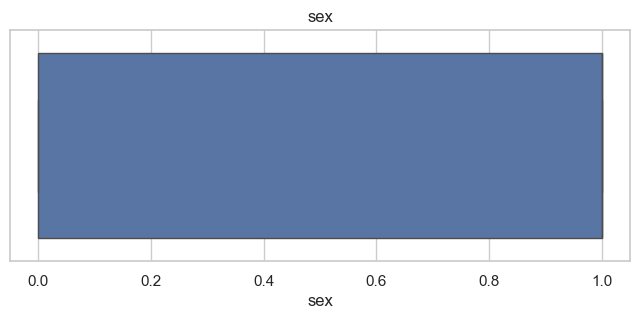

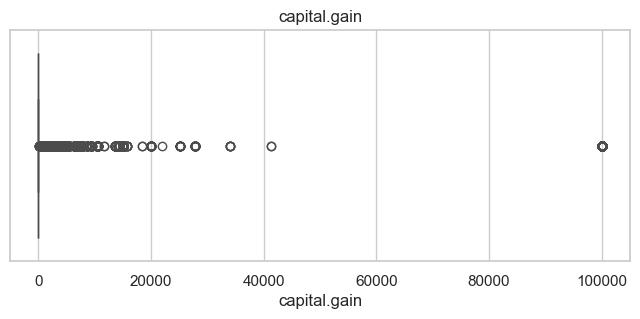

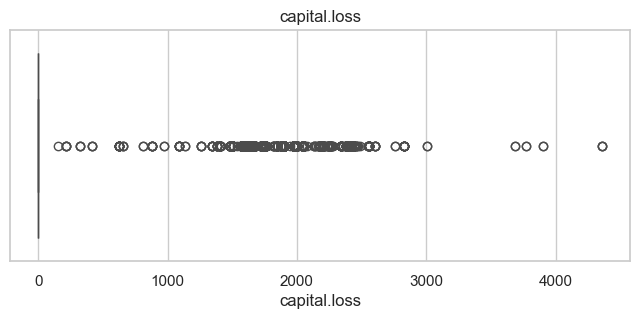

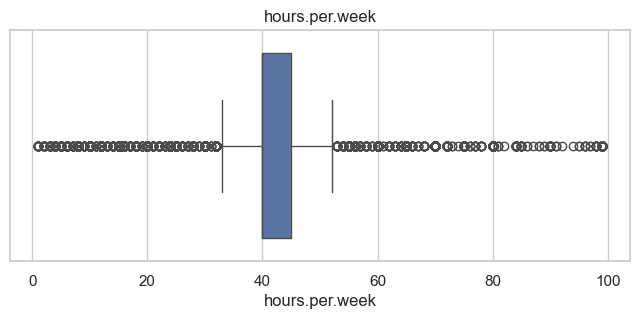

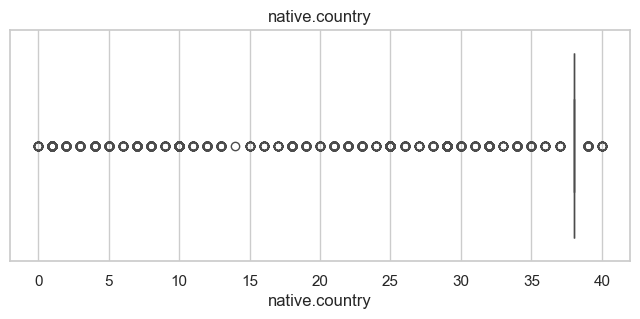

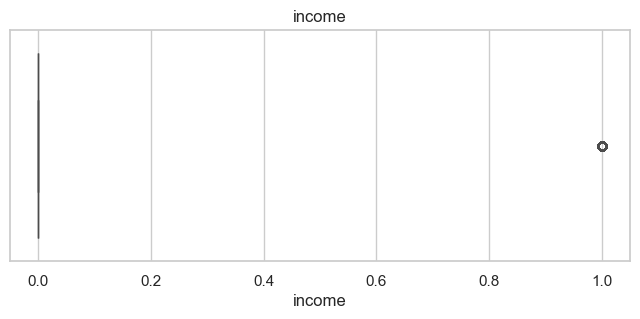

In [5]:
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Correlation Heatmap

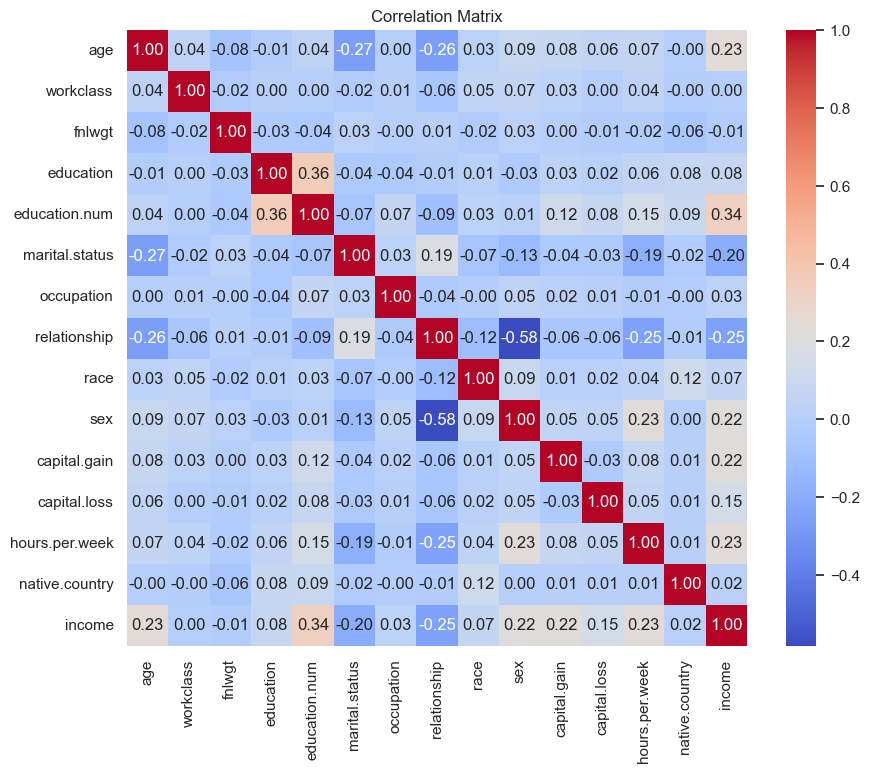

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Pairplot

In [8]:
sns.pairplot(df[numeric_cols.tolist()+["income"]],hue="income",corner=True)
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (32537, 2) instead

## Categorical Feature Distribution

In [17]:
categorical_cols=[c for c in df.columns if c not in numeric_cols and c!="income"]
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(y=col,data=df,order=df[col].value_counts().index)
    plt.title(col)
    plt.tight_layout()
    plt.show()

## Numeric Features vs Income

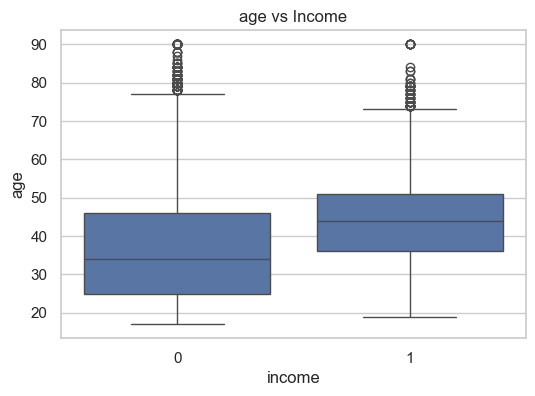

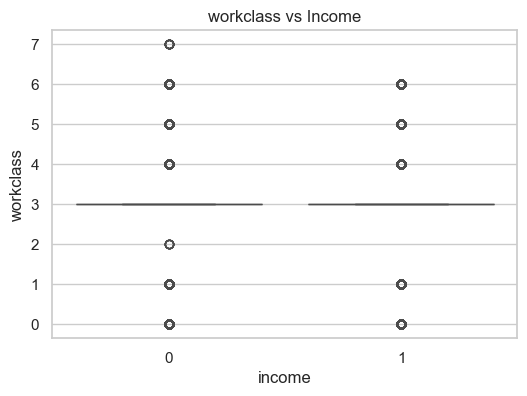

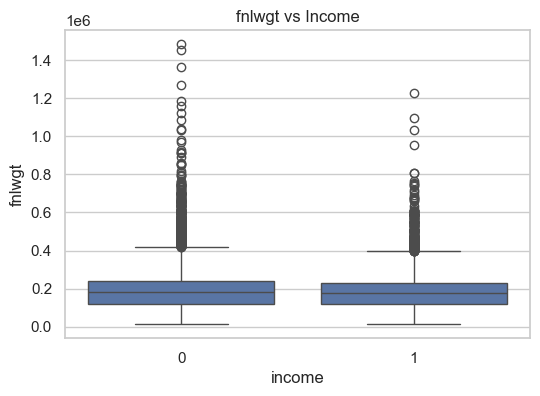

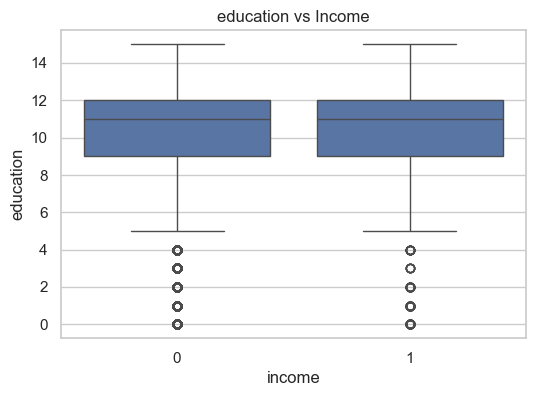

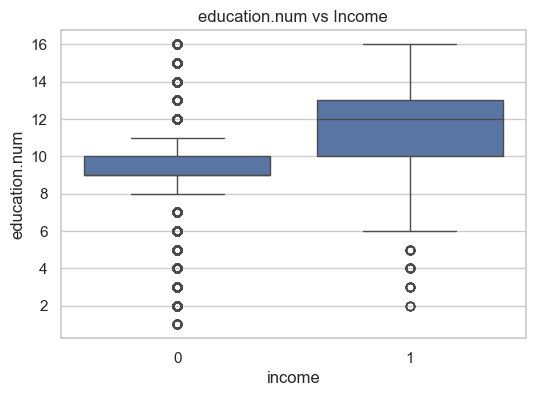

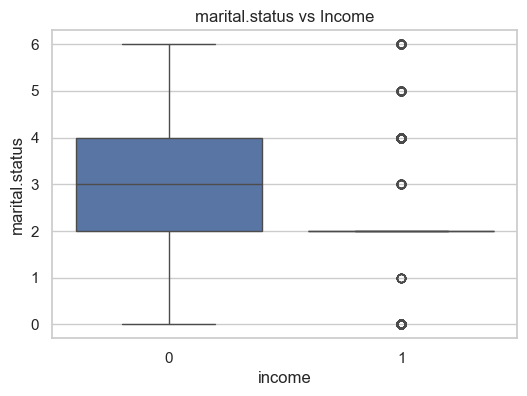

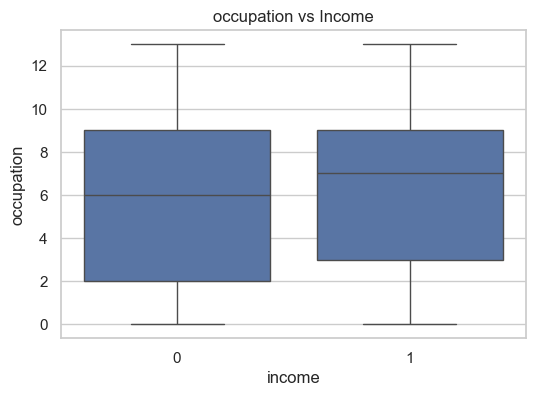

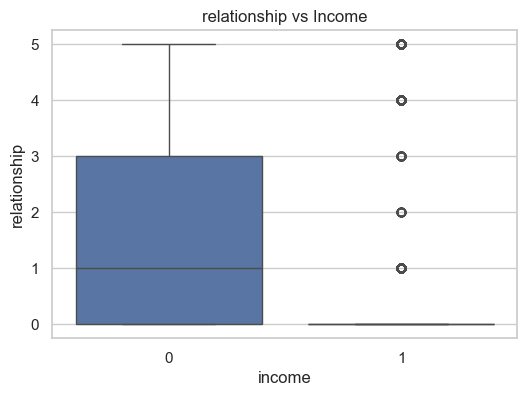

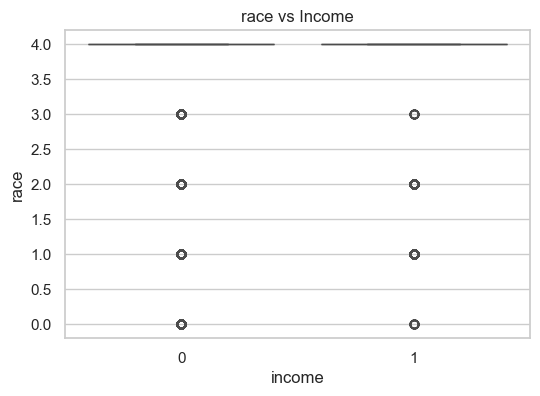

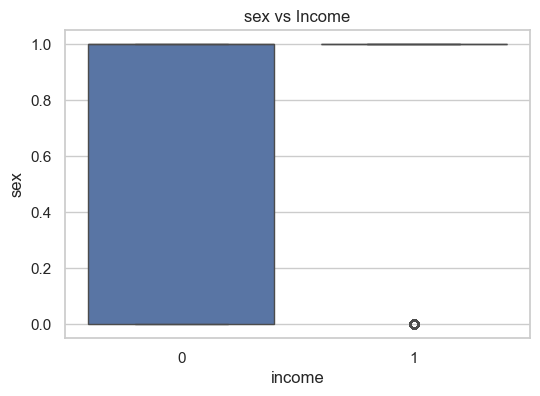

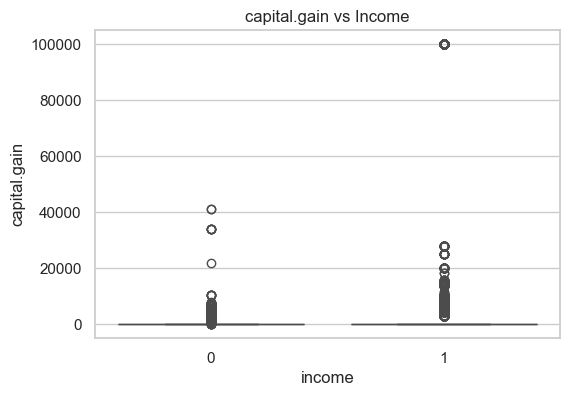

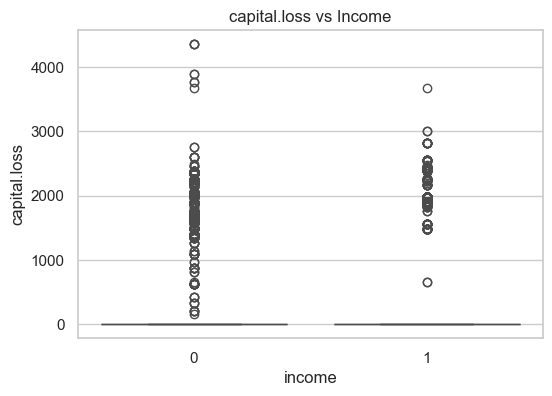

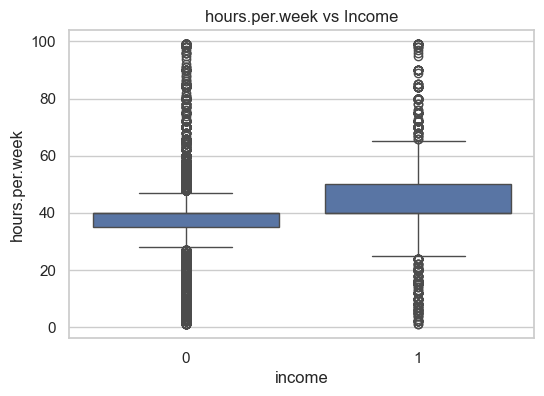

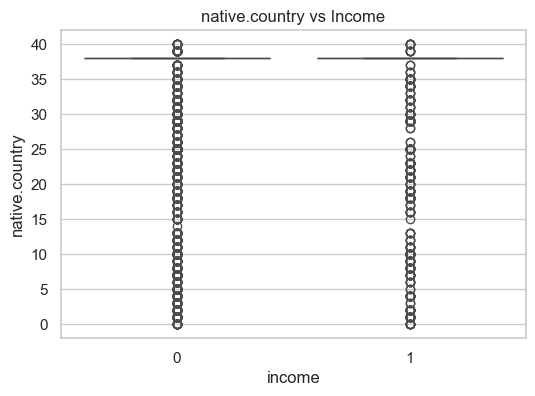

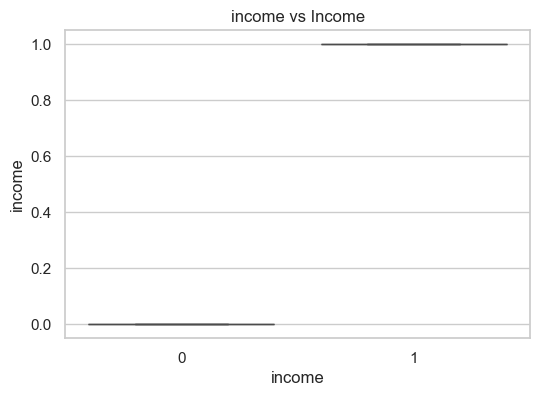

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="income",y=col,data=df)
    plt.title(f"{col} vs Income")
    plt.show()

## Feature Correlation With Target

In [ ]:
corr=df.corr(numeric_only=True)["income"].sort_values(ascending=False)
plt.figure(figsize=(8,5))
corr.drop("income").plot(kind="bar")
plt.ylabel("Correlation")
plt.title("Correlation with Income")
plt.show()